# Brysna UAV Vegetation Classification

Pixel-based vegetation classification of UAV orthomosaics using RGB/HSV thresholds.
Developed for the analysis of vegetation succession on artificial islands in the Szczecin Lagoon.

Author: Dominik Marchowski  
Year: 2025


## Step 1 Vegetation classification overview

This script implements a pixel-based vegetation classification of UAV orthophotos using thresholding in the HSV colour space.  
The procedure is designed to separate vegetated surfaces (grasses, reeds, shrubs) from non-vegetated substrates such as bare sand, gravel and water.

The workflow consists of the following steps:
1. Loading an example UAV orthophoto from an external URL.
2. Conversion of the RGB image to the HSV colour space.
3. Definition of hue, saturation and value thresholds corresponding to green vegetation.
4. Creation of a binary vegetation mask based on these thresholds.
5. Visualisation of the original image and the resulting vegetation mask.

The script is intended for exploratory and reproducible estimation of vegetation cover on newly created artificial islands and can be adapted to full-resolution orthomosaics.



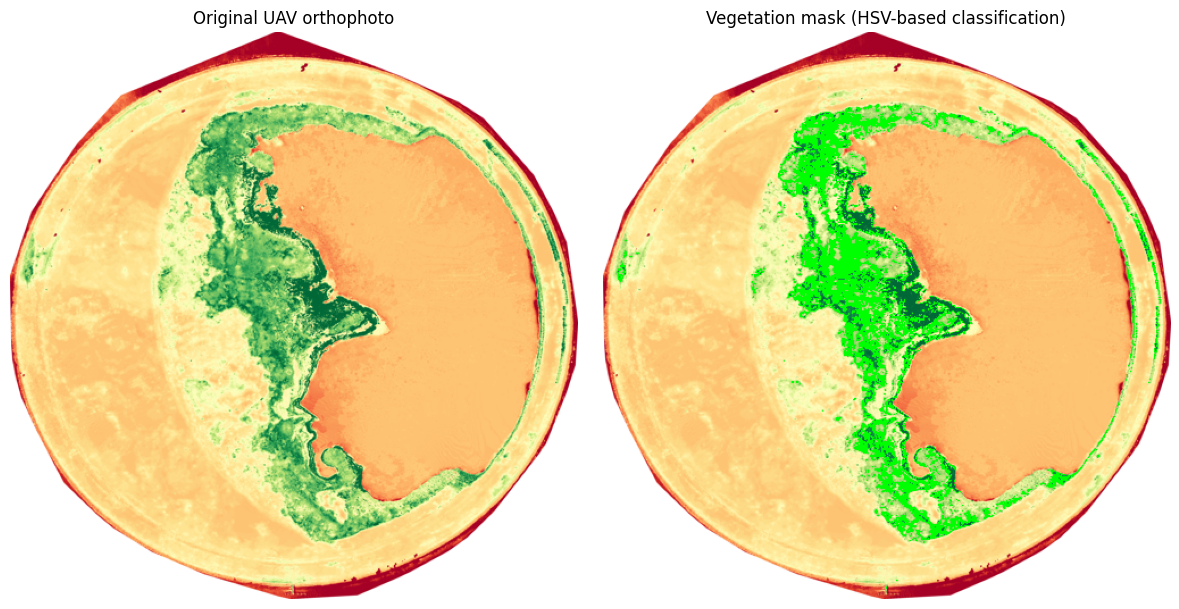

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
import requests
from io import BytesIO

# -------------------------------------------------------------------
# Load example UAV orthophoto directly from URL
# -------------------------------------------------------------------

image_url = "https://marchowski.org/data/brysna/Task-of-2025-08-05T155909126Z-orthophoto-GRVI_Minjpg.jpg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Resize image for faster processing (optional)
image = image.resize((500, 500))
image_np = np.array(image)

# -------------------------------------------------------------------
# Convert RGB image to HSV colour space
# -------------------------------------------------------------------

image_hsv = rgb2hsv(image_np / 255.0)

# -------------------------------------------------------------------
# Define HSV thresholds for green vegetation
# -------------------------------------------------------------------
# Hue range corresponds to green tones
# Saturation and Value thresholds help exclude bare sand and water

hue_min, hue_max = 0.25, 0.40   # Hue range for green vegetation
sat_min, sat_max = 0.30, 1.00   # Saturation range
val_min, val_max = 0.20, 0.80   # Value (brightness) range

# -------------------------------------------------------------------
# Create vegetation mask
# -------------------------------------------------------------------

vegetation_mask = (
    (image_hsv[..., 0] >= hue_min) & (image_hsv[..., 0] <= hue_max) &
    (image_hsv[..., 1] >= sat_min) & (image_hsv[..., 1] <= sat_max) &
    (image_hsv[..., 2] >= val_min) & (image_hsv[..., 2] <= val_max)
)

# -------------------------------------------------------------------
# Create highlighted image showing vegetation pixels
# -------------------------------------------------------------------

highlighted_image = image_np.copy()
highlighted_image[vegetation_mask] = [0, 255, 0]  # Green overlay for vegetation

# -------------------------------------------------------------------
# Visualisation
# -------------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_np)
ax[0].set_title("Original UAV orthophoto")
ax[0].axis("off")

ax[1].imshow(highlighted_image)
ax[1].set_title("Vegetation mask (HSV-based classification)")
ax[1].axis("off")

plt.tight_layout()
plt.show()



## Step 2 – Vegetation classification and coverage estimation
Green vegetation is classified using HSV-based thresholding, and vegetation cover is quantified as the percentage of pixels meeting the vegetation criteria within the analysed orthophoto.


Vegetation cover: 25.46% of image area


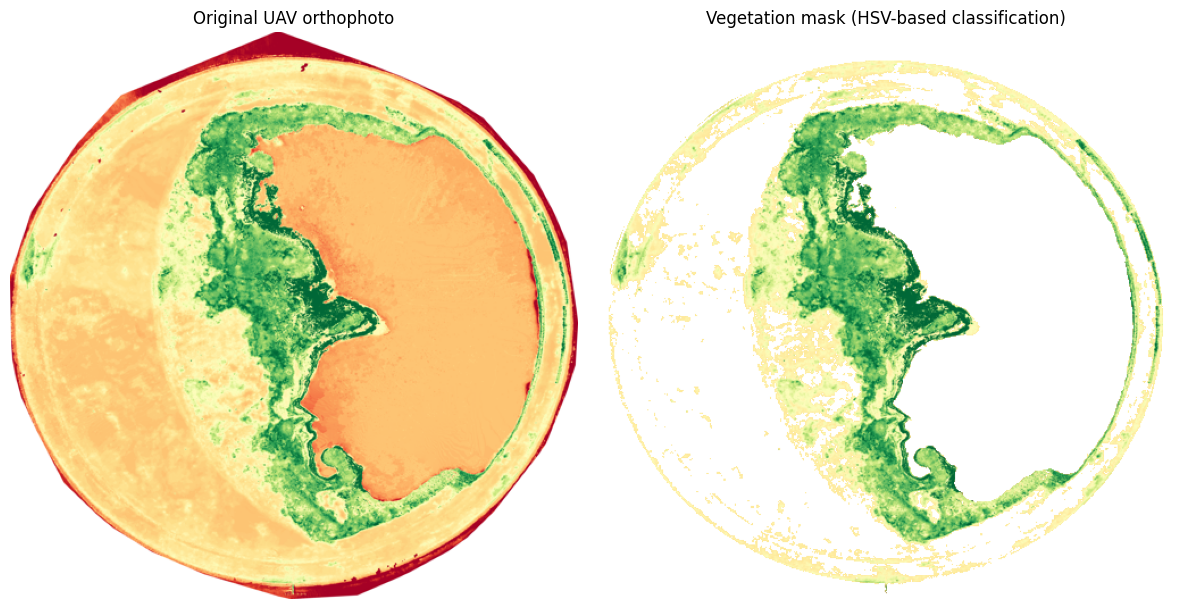

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
import requests
from io import BytesIO

# -------------------------------------------------------------------
# STEP 1: Load example UAV orthophoto from URL
# -------------------------------------------------------------------

image_url = "https://marchowski.org/data/brysna/Task-of-2025-08-05T155909126Z-orthophoto-GRVI_Minjpg.jpg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Optional downscaling for faster processing
image = image.resize((500, 500))
image_np = np.array(image)

# Convert RGB image to HSV colour space
image_hsv = rgb2hsv(image_np / 255.0)

# -------------------------------------------------------------------
# STEP 2: Define HSV thresholds for green vegetation
# -------------------------------------------------------------------
# Thresholds tuned to include grasses, reeds and shrubs,
# while excluding bare sand, gravel and water surfaces

hue_min, hue_max = 0.13, 0.43   # Hue range for green vegetation
sat_min, sat_max = 0.17, 1.00   # Saturation range
val_min, val_max = 0.07, 1.00   # Value (brightness) range

# -------------------------------------------------------------------
# STEP 3: Create binary vegetation mask
# -------------------------------------------------------------------

vegetation_mask = (
    (image_hsv[..., 0] >= hue_min) & (image_hsv[..., 0] <= hue_max) &
    (image_hsv[..., 1] >= sat_min) & (image_hsv[..., 1] <= sat_max) &
    (image_hsv[..., 2] >= val_min) & (image_hsv[..., 2] <= val_max)
)

# -------------------------------------------------------------------
# STEP 4: Calculate percentage vegetation cover
# -------------------------------------------------------------------

green_pixels = np.sum(vegetation_mask)
total_pixels = image_np.shape[0] * image_np.shape[1]

vegetation_coverage_percentage = (green_pixels / total_pixels) * 100

print(f"Vegetation cover: {vegetation_coverage_percentage:.2f}% of image area")

# -------------------------------------------------------------------
# STEP 5: Visualisation of vegetation mask
# -------------------------------------------------------------------
# Non-vegetated pixels are masked out (white background)

highlighted_image = image_np.copy()
highlighted_image[~vegetation_mask] = [255, 255, 255]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_np)
ax[0].set_title("Original UAV orthophoto")
ax[0].axis("off")

ax[1].imshow(highlighted_image)
ax[1].set_title("Vegetation mask (HSV-based classification)")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Step 3 – RGB-based vegetation classification (comparison approach)

This step applies a simple RGB-based thresholding as an alternative classification approach, used for comparison with the HSV-based vegetation mask.


Vegetation cover (RGB-based): 9.81% of image area


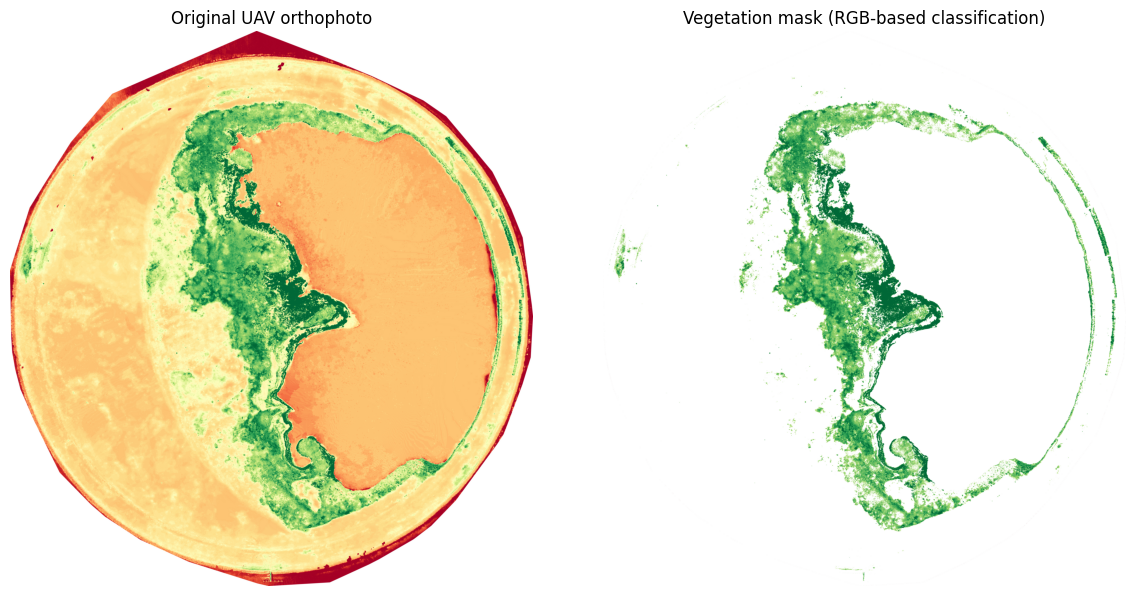

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# -------------------------------------------------------------------
# STEP 3: Alternative RGB-based vegetation classification
# -------------------------------------------------------------------
# This step applies a simple thresholding directly in the RGB colour space.
# It is intended as a comparison method to the HSV-based classification
# and helps assess the sensitivity of vegetation cover estimates to colour space choice.
# -------------------------------------------------------------------

# Load example UAV orthophoto from URL
image_url = "https://marchowski.org/data/brysna/Task-of-2025-08-05T155909126Z-orthophoto-GRVI_Minjpg.jpg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

image_np = np.array(image)

# -------------------------------------------------------------------
# Define RGB thresholds for green vegetation
# -------------------------------------------------------------------
# Green vegetation is characterised by high green-channel values
# and relatively lower red and blue values

red_min, red_max     = 0, 180
green_min, green_max = 80, 255
blue_min, blue_max   = 0, 180

# -------------------------------------------------------------------
# Create RGB-based vegetation mask
# -------------------------------------------------------------------

rgb_vegetation_mask = (
    (image_np[..., 0] >= red_min) & (image_np[..., 0] <= red_max) &
    (image_np[..., 1] >= green_min) & (image_np[..., 1] <= green_max) &
    (image_np[..., 2] >= blue_min) & (image_np[..., 2] <= blue_max)
)

# -------------------------------------------------------------------
# Calculate percentage vegetation cover
# -------------------------------------------------------------------

green_pixels = np.sum(rgb_vegetation_mask)
total_pixels = image_np.shape[0] * image_np.shape[1]

vegetation_coverage_percentage = (green_pixels / total_pixels) * 100

print(f"Vegetation cover (RGB-based): {vegetation_coverage_percentage:.2f}% of image area")

# -------------------------------------------------------------------
# Visualisation of RGB-based vegetation mask
# -------------------------------------------------------------------
# Non-vegetated pixels are masked out (white background)

highlighted_image = image_np.copy()
highlighted_image[~rgb_vegetation_mask] = [255, 255, 255]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_np)
ax[0].set_title("Original UAV orthophoto")
ax[0].axis("off")

ax[1].imshow(highlighted_image)
ax[1].set_title("Vegetation mask (RGB-based classification)")
ax[1].axis("off")

plt.tight_layout()
plt.show()
